# Compound Clustering
Similar compounds might bind to the same targets and show similar effects. Based on this similar property principle, ==compound similarity can be used to build chemical groups via clustering==. From such a clustering, a diverse set of compounds can also be selected from a larger set of screening compounds for further experimental testing.

### Theory
- [] Jarvis-Patrick algorithm

- [] Detailed explanation of Butina clustering

- [] Picking diverse compounds

### Practical
- [] Clustering with the Butina algorithm

- [] Visualizing the clusters

- [] Picking the final list of compounds

- [] Runtime Analysis

> NOTE:
## Jarvis-Patrick Clustering
Clustering method based on similarity between neighbors - determined by using a distance metric. One or more Neighbors in Common are used to judge the cluster membership of the objects under study. The function is deterministic and non-iterative.

**Algorithm Properties**
The algorithm chooses the number of clusters.
There is always at least one item in each cluster.
The algorithm partitions the input into non-hierarchical clusters.
The clusters do not overlap.
If two different items from the input dataset share enough mutual nearest neighbors, then those two items are in the same cluster.

> REMINDER:
>
> Fingerprints are binary vectors where each bit indicates the presence or absence of a particular substructural fragment within a molecule.
>
> Similarity (or distance) matrix: The similarity between each pair of molecules represented by binary fingerprints is typically quantified using the Tanimoto coefficient, which measures the number of common features (bits).
>
> The value of the Tanimoto coefficient ranges from zero (no similarity) to one (high similarity).

Jarvis-Patrick clustering algorithm is defined by two parameters 𝐾 and 𝐾𝑚𝑖𝑛:

Calculate the set of 𝐾 nearest neighbors for each molecule.

Two molecules cluster together if:
- they are in each others list of nearest neighbors.
- they have at least 𝐾𝑚𝑖𝑛 of their 𝐾 nearest neighbors in common.

The Jarvis-Patrick clustering algorithm is deterministic and able to deal with large sets of molecules in a matter of a few hours. However, a downside lies in the fact that this method tends to produce large heterogeneous clusters (see Butina clustering, referenced above).

## Butina Clustering
Identifies smaller but homogeneous clusters, with the prerequisite that (at least) the cluster centroid will be more similar than a given threshold to every other molecule in the cluster.

> **NOTE**
## Key Steps in Clustering Approach
1. **Data preparation and compound encoding:**
To identify chemical similarities, the compounds in the input data (e.g. given as SMILES) will be encoded as molecular fingerprints, e.g., RDK5 fingerprint which is a subgraph-based fingerprint similar to the well known Daylight Fingerprint.

2. **Tanimoto similarity (or distance) matrix:**
- The similarity between two fingerprints is calculated using the Tanimoto coefficient.
- Matrix with Tanimoto similarities between all possible molecule/fingerprint pairs (𝑛 ∗ 𝑛 similarity matrix with 𝑛=number of molecules, upper triangle matrix used only).
- Equally, the distances matrix can be calculated (1 −𝑠⁢𝑖⁢𝑚⁢𝑖⁢𝑙⁢𝑎⁢𝑟⁢𝑖⁢𝑡⁢𝑦).

3. **Clustering molecules: Centroids and exclusion spheres**
Note: Molecules will be clustered together, if they have a maximum distance below a specified cut-off from the cluster centroid (if distance matrix is used) or if they have a minimum similarity above the specified cut-off (if similarity matrix is used).

- Identification of potential cluster centroids
- The cluster centroid is the molecule within a given cluster which has the largest number of neighbors.
- Annotate neighbors: ==For each molecule count all molecules with a Tanimoto distance below a given threshold==.
- Sort molecules by number of neighbors in descending order, so that potential cluster centroids (i.e. the compounds with the largest number of neighbors) are placed at the top.

**Clustering based on the exclusion spheres:**
Starting with the first molecule (centroid) in the sorted list.

- All molecules with a Tanimoto index above or equal to the cut-off value used for clustering then become members of that cluster (in case of similarity).
    - Each molecule that has been identified as a member of the given cluster is flagged and removed from further comparisons. Thus, flagged molecules cannot become either another cluster centroid or a member of another cluster. This process is like putting an exclusion sphere around the newly formed cluster.
    - Once the first compound in the list has found all its neighbors, the first available (i.e. not flagged) compound at the top of the list becomes the new cluster centroid.

The same process is repeated for all other unflagged molecules down the list.

Molecules that have not been flagged by the end of the clustering process become singletons.

Note that some molecules assigned as singletons can have neighbors at the given Tanimoto similarity index, but those neighbors have been excluded by a stronger cluster centroid.

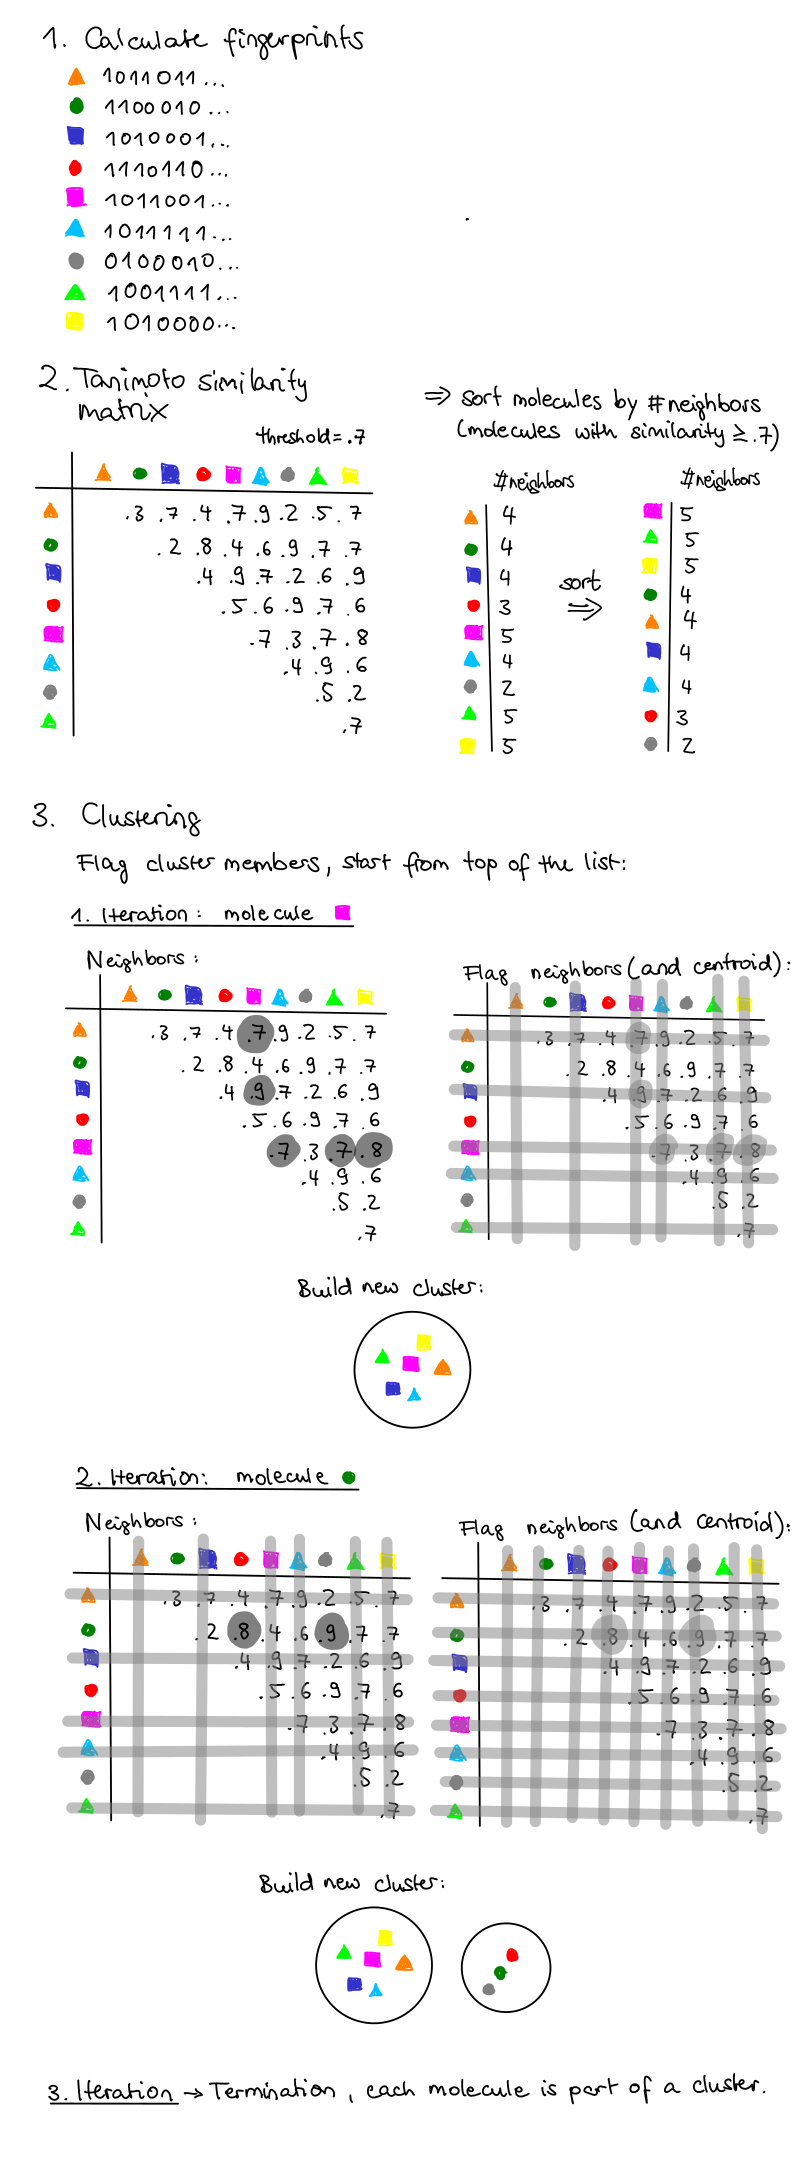

In [1]:
import time
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator

random.seed(0)
np.random.seed(0)
DATA_DIR = "/Users/duncanfreeman/dev/bioinfo/data"

In [2]:
df = pd.read_csv(DATA_DIR + "/EGFR_molecules_ro5_fulfilled.csv", index_col=0)
df.head(2)

,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled
Unnamed: 0,,,,,,,,,,,,,
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,388.265,4.9333,1,5,56.27,6,11.221849,True


In [3]:
df.reset_index(drop=True, inplace=True)

In [6]:
df.drop(columns=["pIC50_old"], inplace=True)
df.shape

(4661, 12)

In [ ]:
# Create molecules from SMILES and store in array with ChEMBL IDs:
compounds = []
for idx, chembl_id, smiles in df[["molecule_chembl_id", "smiles"]].itertuples():
    mol = Chem.MolFromSmiles(smiles)
    compounds.append((mol, chembl_id))
compounds[:5]

[(<rdkit.Chem.rdchem.Mol at 0x115d48120>, 'CHEMBL63786'),
 (<rdkit.Chem.rdchem.Mol at 0x115d48190>, 'CHEMBL35820'),
 (<rdkit.Chem.rdchem.Mol at 0x115d48270>, 'CHEMBL53711'),
 (<rdkit.Chem.rdchem.Mol at 0x115d482e0>, 'CHEMBL66031'),
 (<rdkit.Chem.rdchem.Mol at 0x115d48430>, 'CHEMBL53753')]

In [ ]:
# Create rdkit topological fingerprints for all molecules:
fingerprint_generator = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)
fingerprints = [fingerprint_generator.GetFingerprint(mol) for mol, _ in compounds]
print("Number of compounds converted:", len(fingerprints))
print("Fingerprint length per compound:", len(fingerprints[0]))

Number of compounds converted: 4661
Fingerprint length per compound: 2048


### Get Tanimoto Similarity and Distance Matrix to Identify Potential Cluster Centroids


In [19]:
from rdkit.DataStructs import BulkTanimotoSimilarity
def tanimoto_distance_matrix(fp_list):
    """Calculate condensed distance matrix for fingerprint list."""
    n = len(fp_list)
    dissimilarity_matrix = []

    for i in range(1, n):
        # Calculates similarity of fp_list[i] against fp_list[0...i-1]
        similarities = BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        # Since we need a distance matrix, calculate 1-x for every element in similarity matrix
        dissimilarity_matrix.extend([1.0 - x for x in similarities])

    return dissimilarity_matrix

In [20]:
# Example: Calculate single similarity of two fingerprints
sim = DataStructs.TanimotoSimilarity(fingerprints[0], fingerprints[1])
print(f"Tanimoto similarity: {sim:.2f}, distance: {1-sim:.2f}")
# Example: Calculate distance matrix (distance = 1-similarity)
tanimoto_distance_matrix(fingerprints)[0:5]

Tanimoto similarity: 0.73, distance: 0.27


[0.26996197718631176,
 0.26538461538461533,
 0.40866873065015474,
 0.09345794392523366,
 0.31182795698924726]

In [21]:
# Side note: That looked like a list and not a matrix.
# But it is a triangular similarity matrix in the form of a list
n = len(fingerprints)

# Calculate number of elements in triangular matrix via n*(n-1)/2
elem_triangular_matr = (n * (n - 1)) / 2
print(
    f"Elements in the triangular matrix ({elem_triangular_matr:.0f}) ==",
    f"tanimoto_distance_matrix(fingerprints) ({len(tanimoto_distance_matrix(fingerprints))})",
)

Elements in the triangular matrix (10860130) == tanimoto_distance_matrix(fingerprints) (10860130)


### Clustering molecules: Centroids and exclusion spheres

In [22]:
# Define a clustering function:
def cluster_fingerprints(fingerprints, cutoff=0.2):
    """Cluster fingerprints
    Parameters:
        fingerprints
        cutoff: threshold for the clustering
    """
    # Calculate Tanimoto distance matrix
    distance_matrix = tanimoto_distance_matrix(fingerprints)
    # Now cluster the data with the implemented Butina algorithm:
    clusters = Butina.ClusterData(distance_matrix, len(fingerprints), cutoff, isDistData=True)
    clusters = sorted(clusters, key=len, reverse=True)
    return clusters

In [23]:
# Run the clustering procedure for the dataset
clusters = cluster_fingerprints(fingerprints, cutoff=0.3)

# Give a short report about the numbers of clusters and their sizes
num_clust_g1 = sum(1 for c in clusters if len(c) == 1)
num_clust_g5 = sum(1 for c in clusters if len(c) > 5)
num_clust_g25 = sum(1 for c in clusters if len(c) > 25)
num_clust_g100 = sum(1 for c in clusters if len(c) > 100)

print("total # clusters: ", len(clusters))
print("# clusters with only 1 compound: ", num_clust_g1)
print("# clusters with >5 compounds: ", num_clust_g5)
print("# clusters with >25 compounds: ", num_clust_g25)
print("# clusters with >100 compounds: ", num_clust_g100)


total # clusters:  729
# clusters with only 1 compound:  339
# clusters with >5 compounds:  166
# clusters with >25 compounds:  30
# clusters with >100 compounds:  4


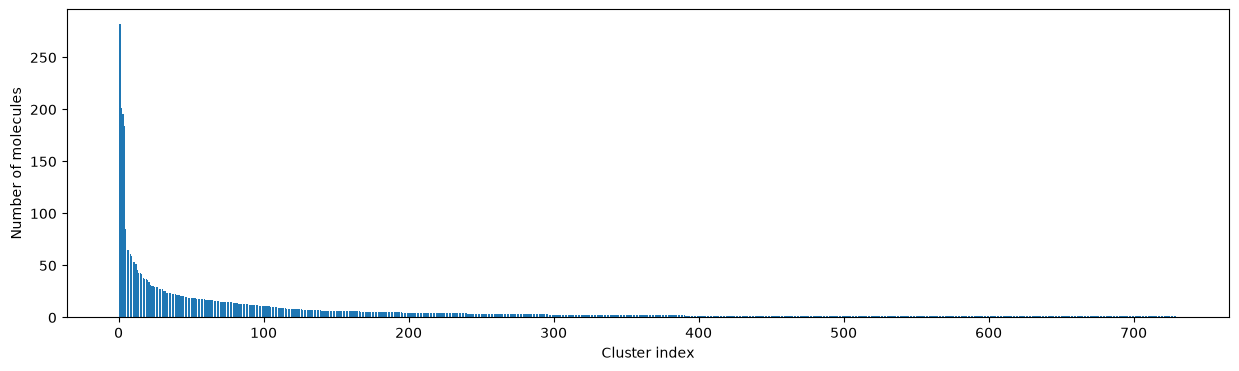

In [24]:
# Plot the size of the clusters
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlabel("Cluster index")
ax.set_ylabel("Number of molecules")
ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5);

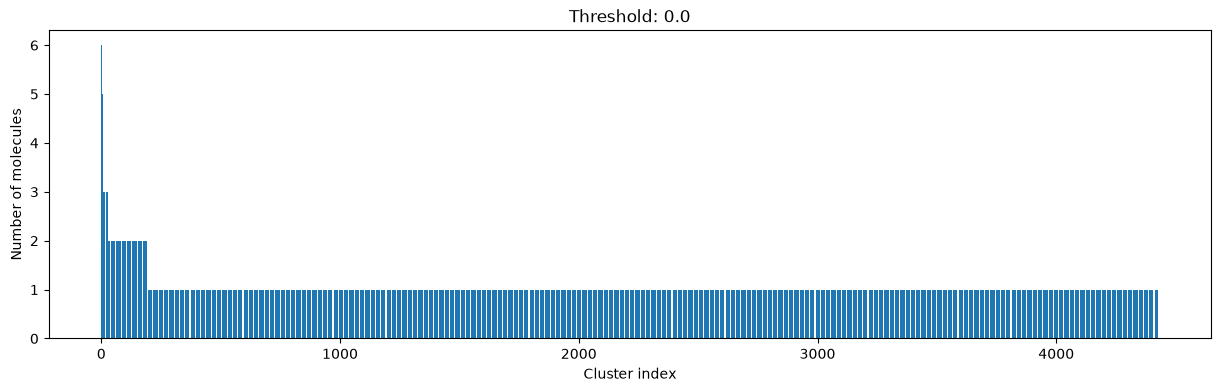

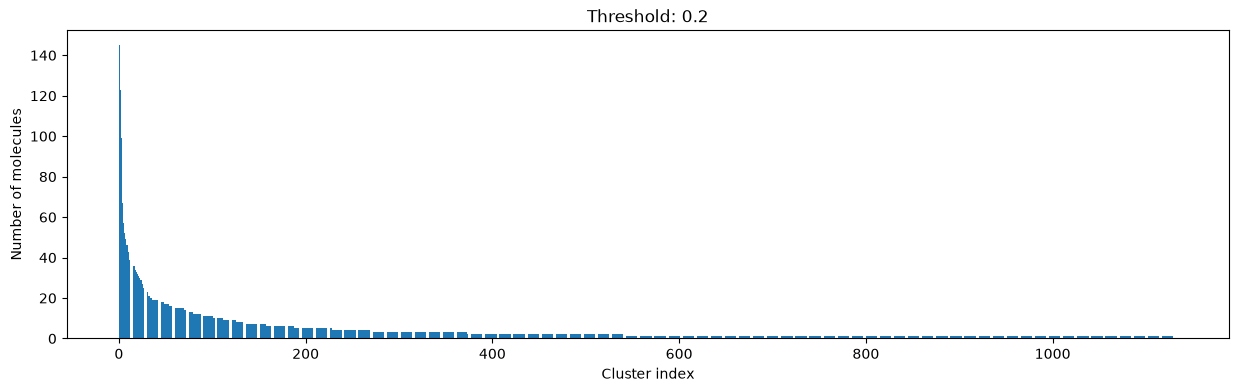

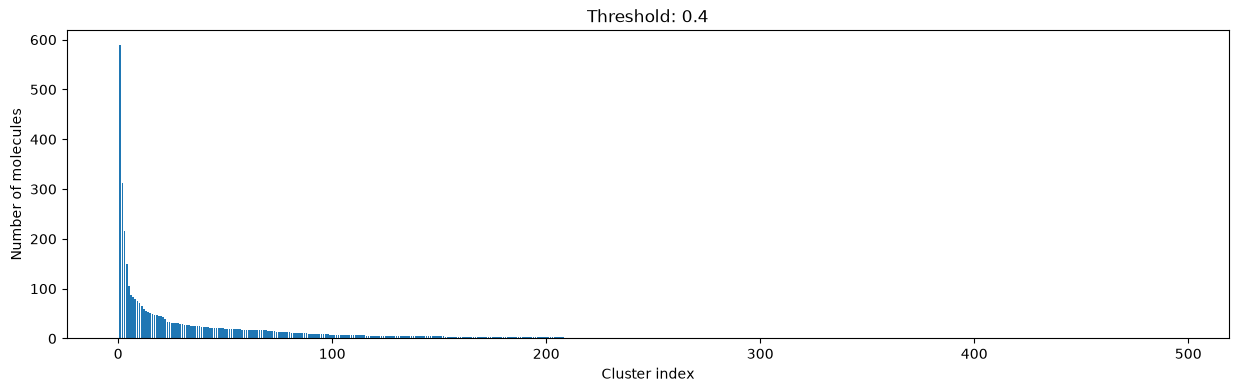

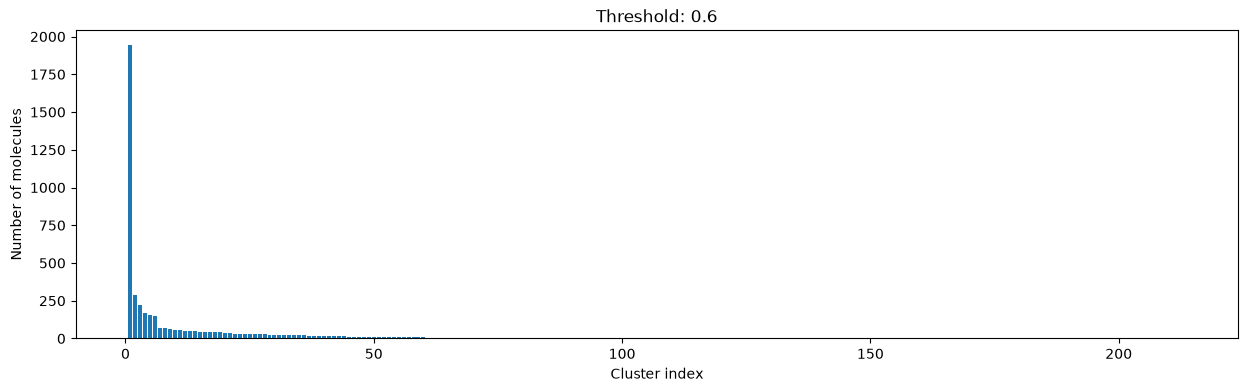

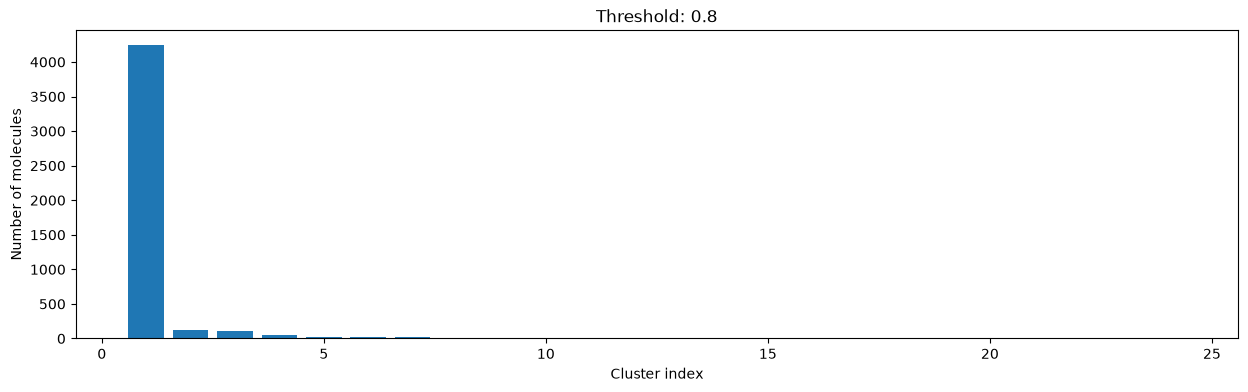

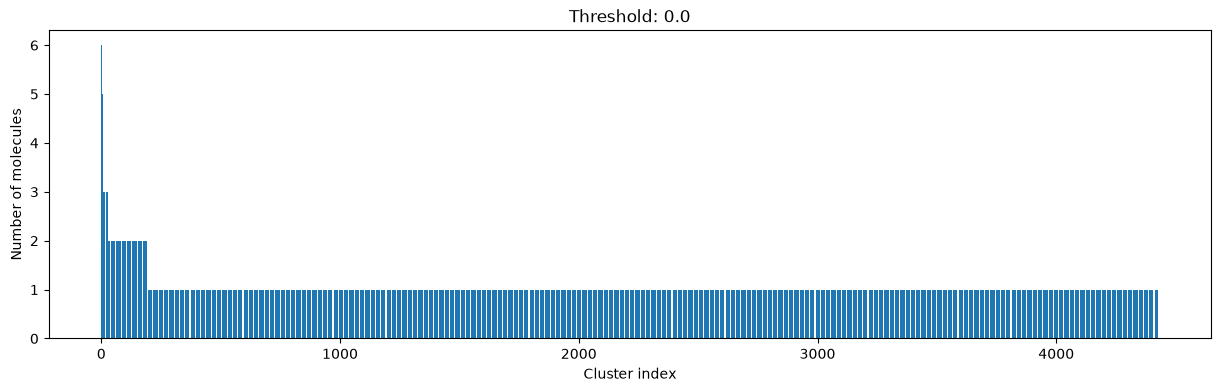

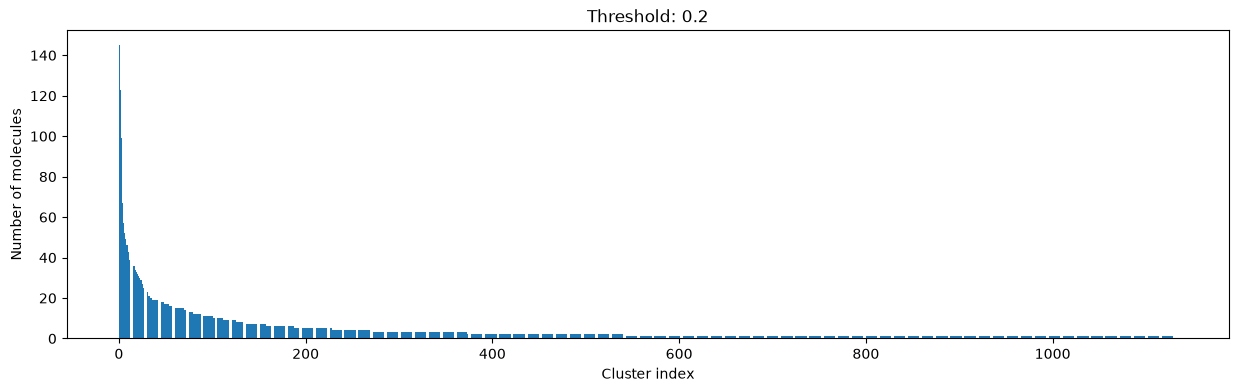

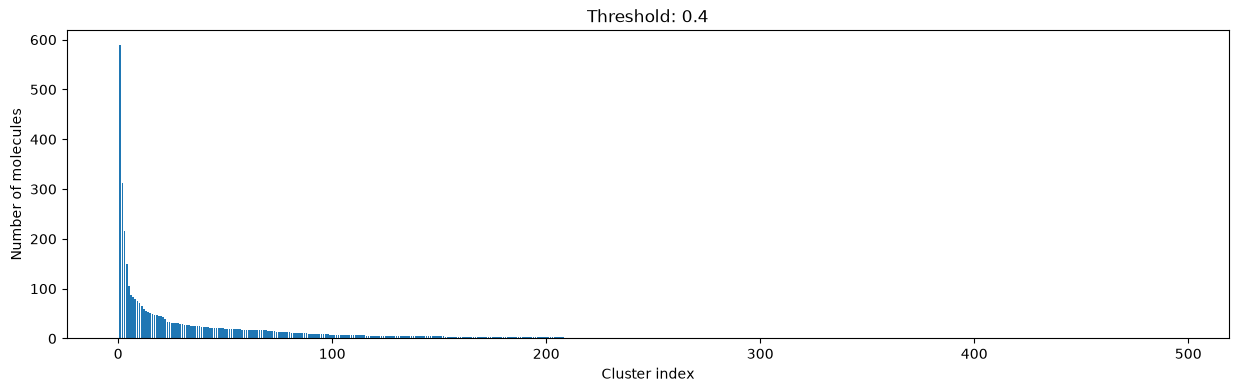

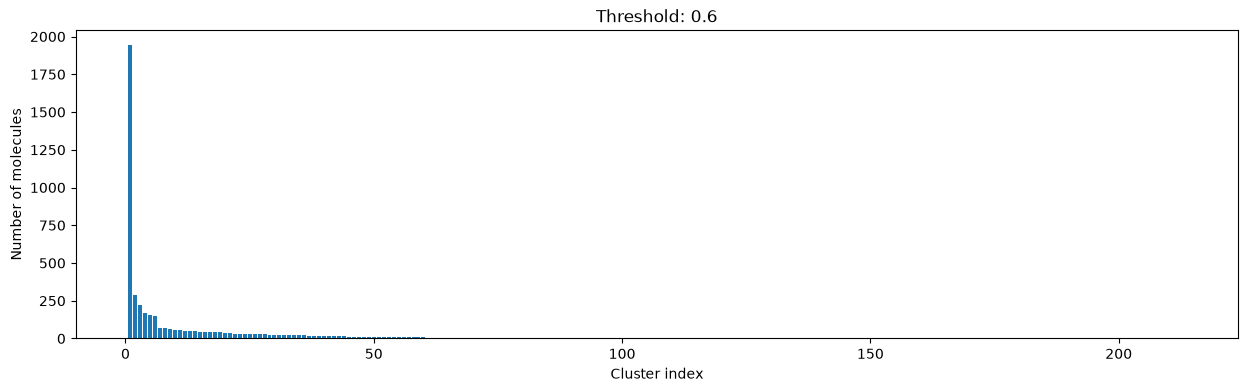

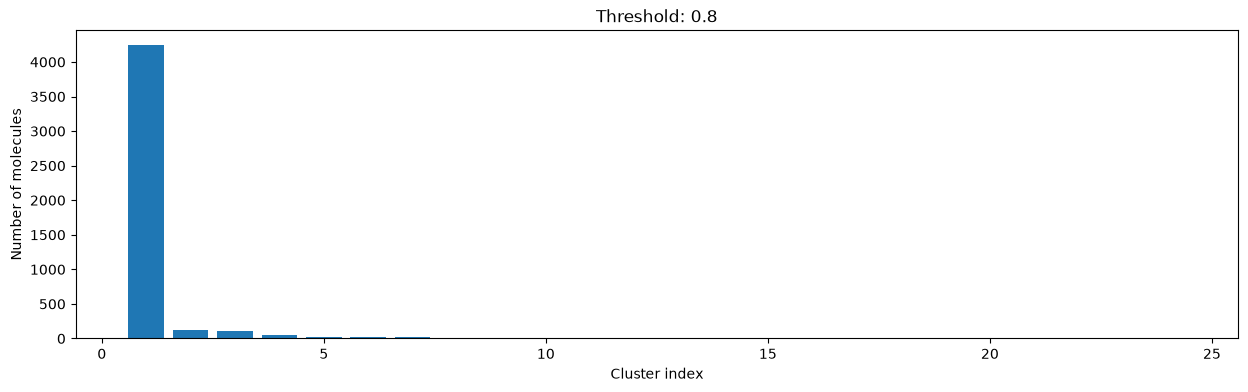

In [28]:
# Since the clustering result depends on the threshold chosen by the user, we will have a closer look on the choice of a cutoff:
for cutoff in np.arange(0.0, 1.0, 0.2):
    clusters = cluster_fingerprints(fingerprints, cutoff=cutoff)
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.set_title(f"Threshold: {cutoff:3.1f}")
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Number of molecules")
    ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5)
    display(fig)

Higher threshold (distance cutoff) = more molecules considered as similar and, thus distrinuted into fewer clusters. 
Lower threshold = more small clusters and “singletons”.

Number of clusters: 1132 from 4661 molecules at distance cut-off 0.20
Number of molecules in largest cluster: 145
Similarity between two random points in same cluster: 0.82
Similarity between two random points in different cluster: 0.22


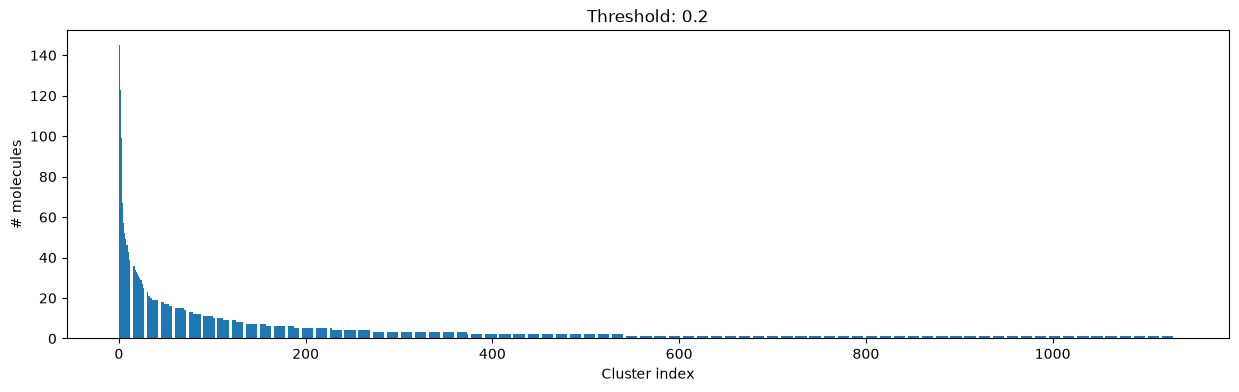

In [31]:
cutoff = 0.2
clusters = cluster_fingerprints(fingerprints, cutoff=cutoff)

# Plot the size of the clusters - save plot
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlabel("Cluster index")
ax.set_ylabel("# molecules")
ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters])
ax.set_title(f"Threshold: {cutoff:3.1f}")
fig.savefig(
    Path(DATA_DIR) / f"cluster_dist_cutoff_{cutoff:4.2f}.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

print(
    f"Number of clusters: {len(clusters)} from {len(compounds)} molecules at distance cut-off {cutoff:.2f}"
)
print("Number of molecules in largest cluster:", len(clusters[0]))
print(
    f"Similarity between two random points in same cluster: {DataStructs.TanimotoSimilarity(fingerprints[clusters[0][0]], fingerprints[clusters[0][1]]):.2f}"
)
print(
    f"Similarity between two random points in different cluster: {DataStructs.TanimotoSimilarity(fingerprints[clusters[0][0]], fingerprints[clusters[1][0]]):.2f}"
)

## Visualize Ten Examples from the Largest Cluster

Ten molecules from largest cluster:


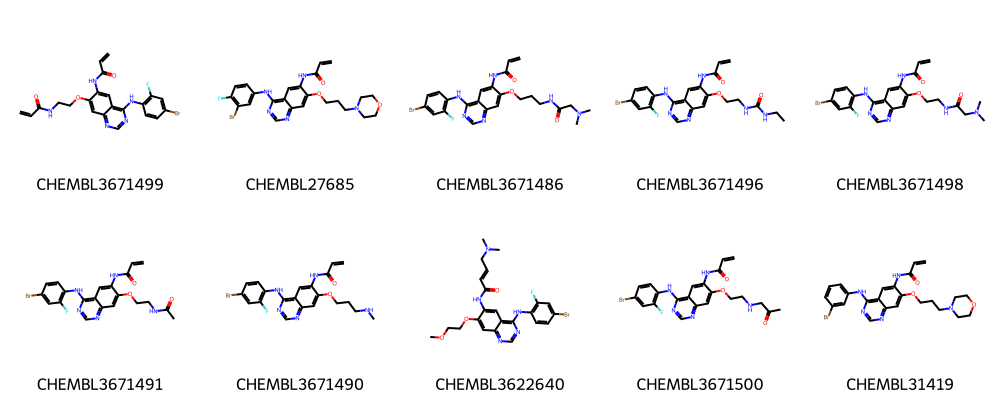

In [32]:
print("Ten molecules from largest cluster:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[i][0] for i in clusters[0][:10]],
    legends=[compounds[i][1] for i in clusters[0][:10]],
    molsPerRow=5,
)

In [34]:
# Save molecules from largest cluster so other talktorials can use it
sdf_path = str(Path(DATA_DIR) / "molecule_set_largest_cluster_t005.sdf")
sdf = Chem.SDWriter(sdf_path)
for index in clusters[0]:
    mol, label = compounds[index]
    # Add label to metadata
    mol.SetProp("_Name", label)
    sdf.write(mol)
sdf.close()

Ten molecules from second largest cluster:


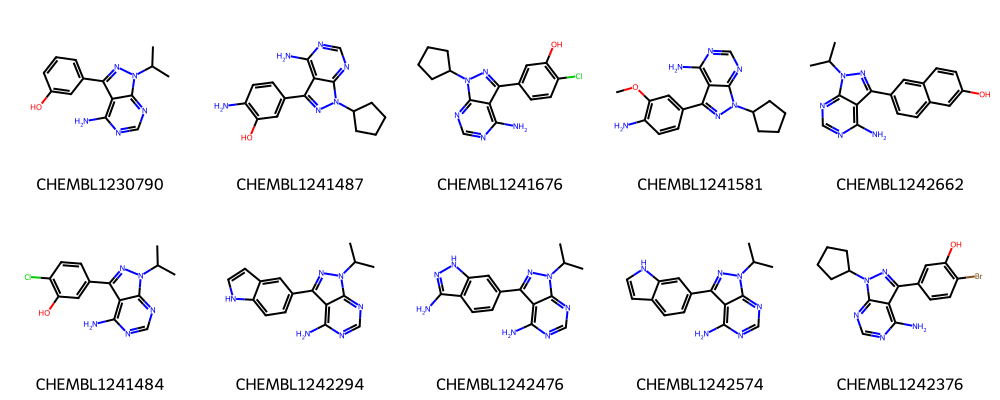

In [ ]:
# 10 examples from 2nd largest cluster...
print("Ten molecules from second largest cluster:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[i][0] for i in clusters[1][:10]],
    legends=[compounds[i][1] for i in clusters[1][:10]],
    molsPerRow=5,
)

### Cluster Centers of First 10 Clusters

Ten molecules from first 10 clusters:


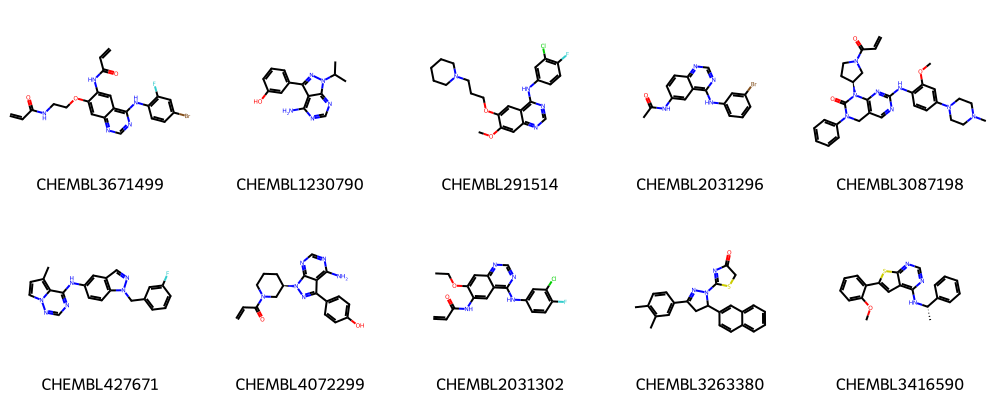

In [36]:
print("Ten molecules from first 10 clusters:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[clusters[i][0]][0] for i in range(10)],
    legends=[compounds[clusters[i][0]][1] for i in range(10)],
    molsPerRow=5,
)

In [37]:
# Generate image
img = Draw.MolsToGridImage(
    [compounds[clusters[i][0]][0] for i in range(0, 3)],
    legends=[f"Cluster {i}" for i in range(1, 4)],
    subImgSize=(200, 200),
    useSVG=True,
)

# Patch RAW svg data: convert non-transparent to transparent background and set font size
molsvg = img.data.replace("opacity:1.0", "opacity:0.0").replace("12px", "20px")

# Save altered SVG data to file
with open(Path(DATA_DIR) / "cluster_representatives_t005.svg", "w") as f:
    f.write(molsvg)

### Intra-cluster Tanimoto similarities

In [38]:
def intra_tanimoto(fps_clusters):
    """Function to compute Tanimoto similarity for all pairs of fingerprints in each cluster"""
    intra_similarity = []
    # Calculate intra similarity per cluster
    for cluster in fps_clusters:
        # Tanimoto distance matrix function converted to similarity matrix (1-distance)
        intra_similarity.append([1 - x for x in tanimoto_distance_matrix(cluster)])
    return intra_similarity

In [40]:
# Recompute fingerprints for 10 first clusters
mol_fps_per_cluster = []
for cluster in clusters[:10]:
    mol_fps_per_cluster.append([fingerprint_generator.GetFingerprint(compounds[i][0]) for i in cluster])

# Compute intra-cluster similarity
intra_sim = intra_tanimoto(mol_fps_per_cluster)

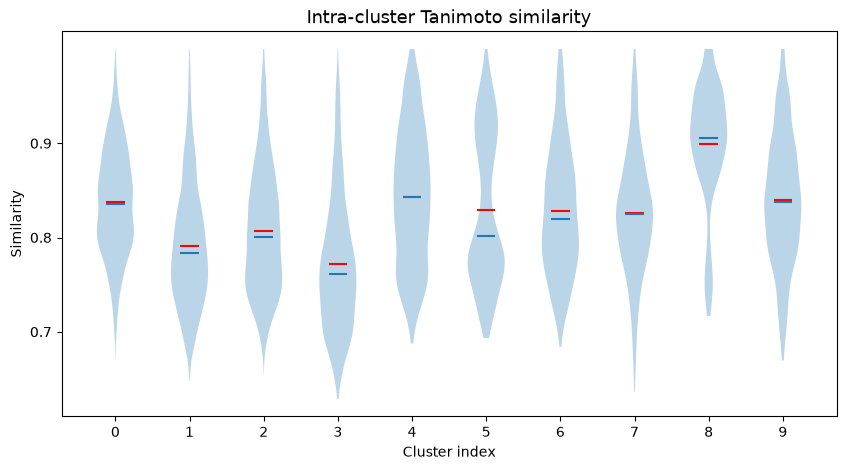

In [41]:
# Violin plot with intra-cluster similarity

fig, ax = plt.subplots(figsize=(10, 5))
indices = list(range(10))
ax.set_xlabel("Cluster index")
ax.set_ylabel("Similarity")
ax.set_xticks(indices)
ax.set_xticklabels(indices)
ax.set_yticks(np.arange(0.6, 1.0, 0.1))
ax.set_title("Intra-cluster Tanimoto similarity", fontsize=13)
r = ax.violinplot(intra_sim, indices, showmeans=True, showmedians=True, showextrema=False)
r["cmeans"].set_color("red")
# mean=red, median=blue

### Select the final list of compounds (max 1000) as a diverse subset

Take the cluster centroid from each cluster (i.e. the first molecule of each cluster).
For each cluster (starting with the largest one) we take the 10 molecules (or 50% if less than 10 molecules are left in the cluster) that are most similar to the centroid, until we have selected max. 1000 compounds. Thus, we have representatives of each cluster.

This ensures the diversity for a smaller set of compounds which are proposed for testing in a confirmatory assay.

> See TDT tutorial notebook by S. Riniker and G. Landrum.

This approach ensures diversity (representatives of each cluster) while getting some SAR (structure-activity relationship) from the results of the confirmatory assay (groups of quite similar molecules from larger clusters retained).



In [42]:
# Get the cluster center of each cluster (first molecule in each cluster):
cluster_centers = [compounds[c[0]] for c in clusters]
# How many cluster centers/clusters do we have?
print("Number of cluster centers:", len(cluster_centers))

Number of cluster centers: 1132


In [44]:
# Sort the molecules within a cluster based on their similarity
# to the cluster center and sort the clusters based on their size
sorted_clusters = []
for cluster in clusters:
    if len(cluster) <= 1:
        continue  # Singletons
    # else:
    # Compute fingerprints for each cluster element
    sorted_fingerprints = [fingerprint_generator.GetFingerprint(compounds[i][0]) for i in cluster]
    # Similarity of all cluster members to the cluster center
    similarities = DataStructs.BulkTanimotoSimilarity(
        sorted_fingerprints[0], sorted_fingerprints[1:]
    )
    # Add index of the molecule to its similarity (centroid excluded!)
    similarities = list(zip(similarities, cluster[1:]))
    # Sort in descending order by similarity
    similarities.sort(reverse=True)
    # Save cluster size and index of molecules in clusters_sort
    sorted_clusters.append((len(similarities), [i for _, i in similarities]))
    # Sort in descending order by cluster size
    sorted_clusters.sort(reverse=True)

In [45]:
# Pick max 1000 compounds
# Count selected molecules, pick cluster centers first
selected_molecules = cluster_centers.copy()
# Take 10 molecules (or a maximum of 50%) of each cluster starting with the largest one
index = 0
pending = 1000 - len(selected_molecules)
while pending > 0 and index < len(sorted_clusters):
    # Take indices of sorted clusters
    tmp_cluster = sorted_clusters[index][1]
    # If the first cluster is > 10 big then take exactly 10 compounds
    if sorted_clusters[index][0] > 10:
        num_compounds = 10
    # If smaller, take half of the molecules
    else:
        num_compounds = int(0.5 * len(tmp_cluster)) + 1
    if num_compounds > pending:
        num_compounds = pending
    # Write picked molecules and their structures into list of lists called picked_fps
    selected_molecules += [compounds[i] for i in tmp_cluster[:num_compounds]]
    index += 1
    pending = 1000 - len(selected_molecules)
print("# Selected molecules:", len(selected_molecules))

# Selected molecules: 1132


## Analyze Runtimes (Butina Clustering)

In [47]:
print(compounds[:5])

[(<rdkit.Chem.rdchem.Mol object at 0x115d48120>, 'CHEMBL63786'), (<rdkit.Chem.rdchem.Mol object at 0x115d48190>, 'CHEMBL35820'), (<rdkit.Chem.rdchem.Mol object at 0x115d48270>, 'CHEMBL53711'), (<rdkit.Chem.rdchem.Mol object at 0x115d482e0>, 'CHEMBL66031'), (<rdkit.Chem.rdchem.Mol object at 0x115d48430>, 'CHEMBL53753')]


In [48]:
# Helper function for time computation
def measure_runtime(sampled_mols: list) -> float:
    """
    Measure runtime for clustering a sample of molecules.
    
    Parameters:
        sampled_mols: list of tuples (mol, index) of sampled molecules
    Returns:
        float: time taken to cluster the sampled molecules
    """

    fingerprint_generator = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)
    start_time = time.time()
    sampled_fingerprints = [fingerprint_generator.GetFingerprint(m) for m, idx in sampled_mols]
    # Run the clustering with the dataset
    sampled_clusters = cluster_fingerprints(sampled_fingerprints, cutoff=0.3)
    return time.time() - start_time

In [50]:
sampled_mols = compounds.copy()
len(sampled_mols)

4661

In [51]:
sample_sizes = [100, 500, 1000, 2000, 4000]
runtimes = []
# Take random samples with replacement
for size in sample_sizes:
    time_taken = measure_runtime(random.sample(sampled_mols, size))
    print(f"Dataset size {size}, time {time_taken:4.2f} seconds")
    runtimes.append(time_taken)

Dataset size 100, time 0.04 seconds
Dataset size 500, time 0.14 seconds
Dataset size 1000, time 0.32 seconds
Dataset size 2000, time 0.73 seconds
Dataset size 4000, time 2.25 seconds


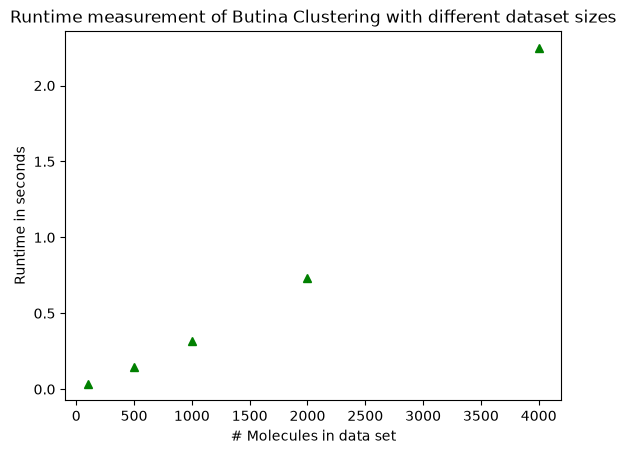

In [52]:
fig, ax = plt.subplots()
ax.set_title("Runtime measurement of Butina Clustering with different dataset sizes")
ax.set_xlabel("# Molecules in data set")
ax.set_ylabel("Runtime in seconds")
ax.plot(sample_sizes, runtimes, "g^");

> NOTE:
Why is clustering of molecules important?
The clustering of molecules facilitates grouping of similar chemical compounds or biological structures together. This helps reduce large, complex datasets, optimize cellular and biological signaling functions, and accelerate drug discovery by prioritizing high-potential compounds.
**Biological Importance**
- Cell signaling: Enhances communication and efficiency within cell membranes.
- Structural organization: Provides an intermediate bridge between molecular components and cellular function.
- Protein folding: Helps map and organize conformational states in protein structure predictions.

**Computational and Drug Discovery Importance**
- Data reduction: Simplifies massive virtual libraries containing millions of compounds.
- Pattern recognition: Identifies structural scaffolds and shared properties among active molecules.
- Diversity selection: Picks representative subsets for physical lab testing, saving time and money.

Which algorithms can you use to cluster a set of molecules and what is the general idea behind the algorithm?
K-Means, Hierarchical Clustering, Butina clustering, and Graph-based algorithms. These methods group similar chemical structures together based on molecular fingerprints or descriptors to help find common patterns in large chemical libraries.

Do you know other clustering algorithms?
- Butina Algorithm: A neighbor-based, non-hierarchical approach that sorts molecules by their number of neighbors within a specific similarity cutoff, highly favored in drug discovery for finding dense, homogeneous clusters.
- MaxMin Clustering: A diversity-maximizing, centroid-based method that iteratively picks representative cluster centers as far apart as possible before assigning remaining molecules.
- Hierarchical (Ward's Method): Builds a tree of clusters by minimizing variance within merged groups, useful for small-to-medium datasets but scales poorly with size.
- Dimensionality Reduction + GMM/K-Means: Modern pipelines project high-dimensional fingerprints into low-dimensional space via UMAP or t-SNE, then apply Gaussian Mixture Models or K-means (such as SOMoC).
- BitBIRCH: An ultra-fast tree-based algorithm engineered to cluster millions to billions of molecules efficiently without massive memory overhead